Нужные библиотеки

In [ ]:
import kagglehub
import os
import numpy as np
from PIL import Image
from pycocotools.coco import COCO
import tensorflow as tf
import cv2
import numpy as np
from tensorflow.keras import layers, models
import albumentations as A
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import drive
import matplotlib.pyplot as plt
import random
from tensorflow.keras.callbacks import CSVLogger
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score
import seaborn as sns

# Подключаем Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


Скачиваем данные с кеггли

In [ ]:
path = kagglehub.dataset_download("pkdarabi/brain-tumor-image-dataset-semantic-segmentation")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/brain-tumor-image-dataset-semantic-segmentation


Загрузка данных в переменные

In [ ]:
train_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/train'
val_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid'

train_ann_file = os.path.join(train_dir, '_annotations.coco.json')
val_ann_file = os.path.join(val_dir, '_annotations.coco.json')


train_coco = COCO(train_ann_file)
val_coco = COCO(val_ann_file)

def load_image_and_mask(coco, image_dir, image_id):
    # Load image info and image file path
    image_info = coco.loadImgs(image_id)[0]
    image_path = os.path.join(image_dir, image_info['file_name'])
    image = Image.open(image_path).convert('RGB')  # convert to RGB
    image = np.array(image)


    mask = np.zeros((image_info['height'], image_info['width']), dtype=np.uint8)


    ann_ids = coco.getAnnIds(imgIds=image_id)
    anns = coco.loadAnns(ann_ids)


    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    return image, mask

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Предварительная обработка изображений и маски

In [ ]:
def preprocess_image_and_mask(image, mask, img_size=(128, 128)):

    if image.ndim == 3 and image.shape[-1] == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)  # or BGR2GRAY depending on cv2.imread

    image = cv2.resize(image, img_size)
    mask = cv2.resize(mask, img_size, interpolation=cv2.INTER_NEAREST)

    image = image / 255.0
    mask = (mask > 0).astype(np.float32)

    # Add channel dims
    image = np.expand_dims(image, axis=-1)
    mask = np.expand_dims(mask, axis=-1)

    return image, mask

Добавление аугментации

In [ ]:
augmentation = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], additional_targets={'mask': 'mask'})

def augment_image_and_mask(image, mask):
    augmented = augmentation(image=image, mask=mask)
    return augmented['image'], augmented['mask']

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Генератор данных, который создает батчи (пакеты) изображений и масок для обучения нейросети.

In [ ]:
def data_generator(coco, image_dir, batch_size=16, augment_func=None, img_size=(128,128)):
    img_ids = coco.getImgIds()
    n = len(img_ids)
    while True:
        np.random.shuffle(img_ids)
        for i in range(0, n, batch_size):
            batch_ids = img_ids[i:i+batch_size]
            images = []
            masks = []
            for img_id in batch_ids:
                img, mask = load_image_and_mask(coco, image_dir, img_id)
                if augment_func:
                    img, mask = augment_func(img, mask)
                img, mask = preprocess_image_and_mask(img, mask, img_size)
                images.append(img)
                masks.append(mask)
            yield np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

Модель U-net

In [ ]:
def build_unet(input_shape=(128, 128, 1)):
    inputs = layers.Input(input_shape)

    # --- Encoder with BatchNorm ---
    # Block 1
    c1 = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('relu')(c1)
    c1 = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(c1)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('relu')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    p1 = layers.Dropout(0.1)(p1)

    # Block 2
    c2 = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('relu')(c2)
    c2 = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(c2)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('relu')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    p2 = layers.Dropout(0.1)(p2)

    # Block 3
    c3 = layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('relu')(c3)
    c3 = layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(c3)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('relu')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    p3 = layers.Dropout(0.2)(p3)

    # Block 4
    c4 = layers.Conv2D(512, 3, padding='same', kernel_initializer='he_normal')(p3)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Activation('relu')(c4)
    c4 = layers.Conv2D(512, 3, padding='same', kernel_initializer='he_normal')(c4)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Activation('relu')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)
    p4 = layers.Dropout(0.2)(p4)

    # --- Bottleneck with more dropout ---
    c5 = layers.Conv2D(1024, 3, padding='same', kernel_initializer='he_normal')(p4)
    c5 = layers.BatchNormalization()(c5)
    c5 = layers.Activation('relu')(c5)
    c5 = layers.Conv2D(1024, 3, padding='same', kernel_initializer='he_normal')(c5)
    c5 = layers.BatchNormalization()(c5)
    c5 = layers.Activation('relu')(c5)
    c5 = layers.Dropout(0.3)(c5)

    # --- Decoder with Transpose Convs ---
    # Block 6
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    u6 = layers.Dropout(0.2)(u6)
    c6 = layers.Conv2D(512, 3, padding='same', kernel_initializer='he_normal')(u6)
    c6 = layers.BatchNormalization()(c6)
    c6 = layers.Activation('relu')(c6)
    c6 = layers.Conv2D(512, 3, padding='same', kernel_initializer='he_normal')(c6)
    c6 = layers.BatchNormalization()(c6)
    c6 = layers.Activation('relu')(c6)

    # Block 7
    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    u7 = layers.Dropout(0.2)(u7)
    c7 = layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(u7)
    c7 = layers.BatchNormalization()(c7)
    c7 = layers.Activation('relu')(c7)
    c7 = layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(c7)
    c7 = layers.BatchNormalization()(c7)
    c7 = layers.Activation('relu')(c7)

    # Block 8
    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    u8 = layers.Dropout(0.1)(u8)
    c8 = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(u8)
    c8 = layers.BatchNormalization()(c8)
    c8 = layers.Activation('relu')(c8)
    c8 = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(c8)
    c8 = layers.BatchNormalization()(c8)
    c8 = layers.Activation('relu')(c8)

    # Block 9
    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    u9 = layers.Dropout(0.1)(u9)
    c9 = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(u9)
    c9 = layers.BatchNormalization()(c9)
    c9 = layers.Activation('relu')(c9)
    c9 = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(c9)
    c9 = layers.BatchNormalization()(c9)
    c9 = layers.Activation('relu')(c9)

    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

Нужные метрики

In [ ]:
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    dice = dice_loss(y_true, y_pred)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.6 * dice + 0.4 * bce

In [ ]:
initial_learning_rate = 1e-4
optimizer = tf.keras.optimizers.Adam(learning_rate=initial_learning_rate)

model = build_unet(input_shape=(128,128,1))
model.compile(optimizer=optimizer, loss=combined_loss, metrics=[dice_coef, iou_metric, "accuracy"])

train_gen = data_generator(train_coco, train_dir, batch_size=16, augment_func=augment_image_and_mask)
val_gen = data_generator(val_coco, val_dir, batch_size=16, augment_func=None)

steps_per_epoch = len(train_coco.getImgIds()) // 16
validation_steps = len(val_coco.getImgIds()) // 16

# 1. Callback для уменьшения learning rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',  # Следим за валидационной accuracy
    mode='max',            # Максимизируем метрику
    factor=0.5,            # Уменьшаем LR в 2 раза
    patience=5,            # Ждём 5 эпох без улучшения
    min_lr=1e-6,           # Минимальный learning rate
    verbose=1              # Вывод сообщений
)

# 2. Callback для ранней остановки
early_stopping = EarlyStopping(
    monitor='val_accuracy',  # Критерий - валидационная accuracy
    mode='max',             # Максимизируем метрику
    patience=20,            # Ждём 20 эпох без улучшения
    baseline=0.99,          # Минимальный целевой порог
    restore_best_weights=True,  # Восстанавливаем лучшие веса
    verbose=1               # Вывод сообщений
)

Запуск обучения

In [ ]:
csv_logger = CSVLogger('/content/drive/MyDrive/unet/training_history.csv')

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=100,
    callbacks=[early_stopping, reduce_lr, csv_logger]
)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_310']
Received: inputs=Tensor(shape=(None, 128, 128, 1))
  warnings.warn(msg)


93/93 ━━━━━━━━━━━━━━━━━━━━ 61s 317ms/step - accuracy: 0.6113 - dice_coef: 0.0774 - iou_metric: 0.0403 - loss: 1.6042 - val_accuracy: 0.9469 - val_dice_coef: 0.0736 - val_iou_metric: 0.0382 - val_loss: 1.3731 - learning_rate: 1.0000e-04
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 45s 282ms/step - accuracy: 0.9564 - dice_coef: 0.0960 - iou_metric: 0.0506 - loss: 1.1447 - val_accuracy: 0.8724 - val_dice_coef: 0.0977 - val_iou_metric: 0.0514 - val_loss: 1.2543 - learning_rate: 1.0000e-04
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 41s 443ms/step - accuracy: 0.9463 - dice_coef: 0.2011 - iou_metric: 0.1121 - loss: 1.0038 - val_accuracy: 0.9512 - val_dice_coef: 0.1441 - val_iou_metric: 0.0778 - val_loss: 1.0566 - learning_rate: 1.0000e-04
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 41s 448ms/step - accuracy: 0.9537 - dice_coef: 0.2564 - iou_metric: 0.1475 - loss: 0.9161 - val_accuracy: 0.9452 - val_dice_coef: 0.2252 - val_iou_metric: 0.1272 - val_loss: 0.9804 - learning_rate: 1.0000e-04
Epoch 5/100
93/93 ━━

Сохранение обученной нейросети

In [ ]:
# Путь для сохранения модели
MODEL_PATH = '/content/drive/MyDrive/Colab_Models/brain_tumor_unetv2.h5'

# Создаем папку, если её нет
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

model.save(MODEL_PATH,
           save_format='h5',
           include_optimizer=True)
print(f"Модель сохранена в: {MODEL_PATH}")

Модель сохранена в: /content/drive/MyDrive/Colab_Models/brain_tumor_unetv2.h5


Предсказания на тестовых фотографиях

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step


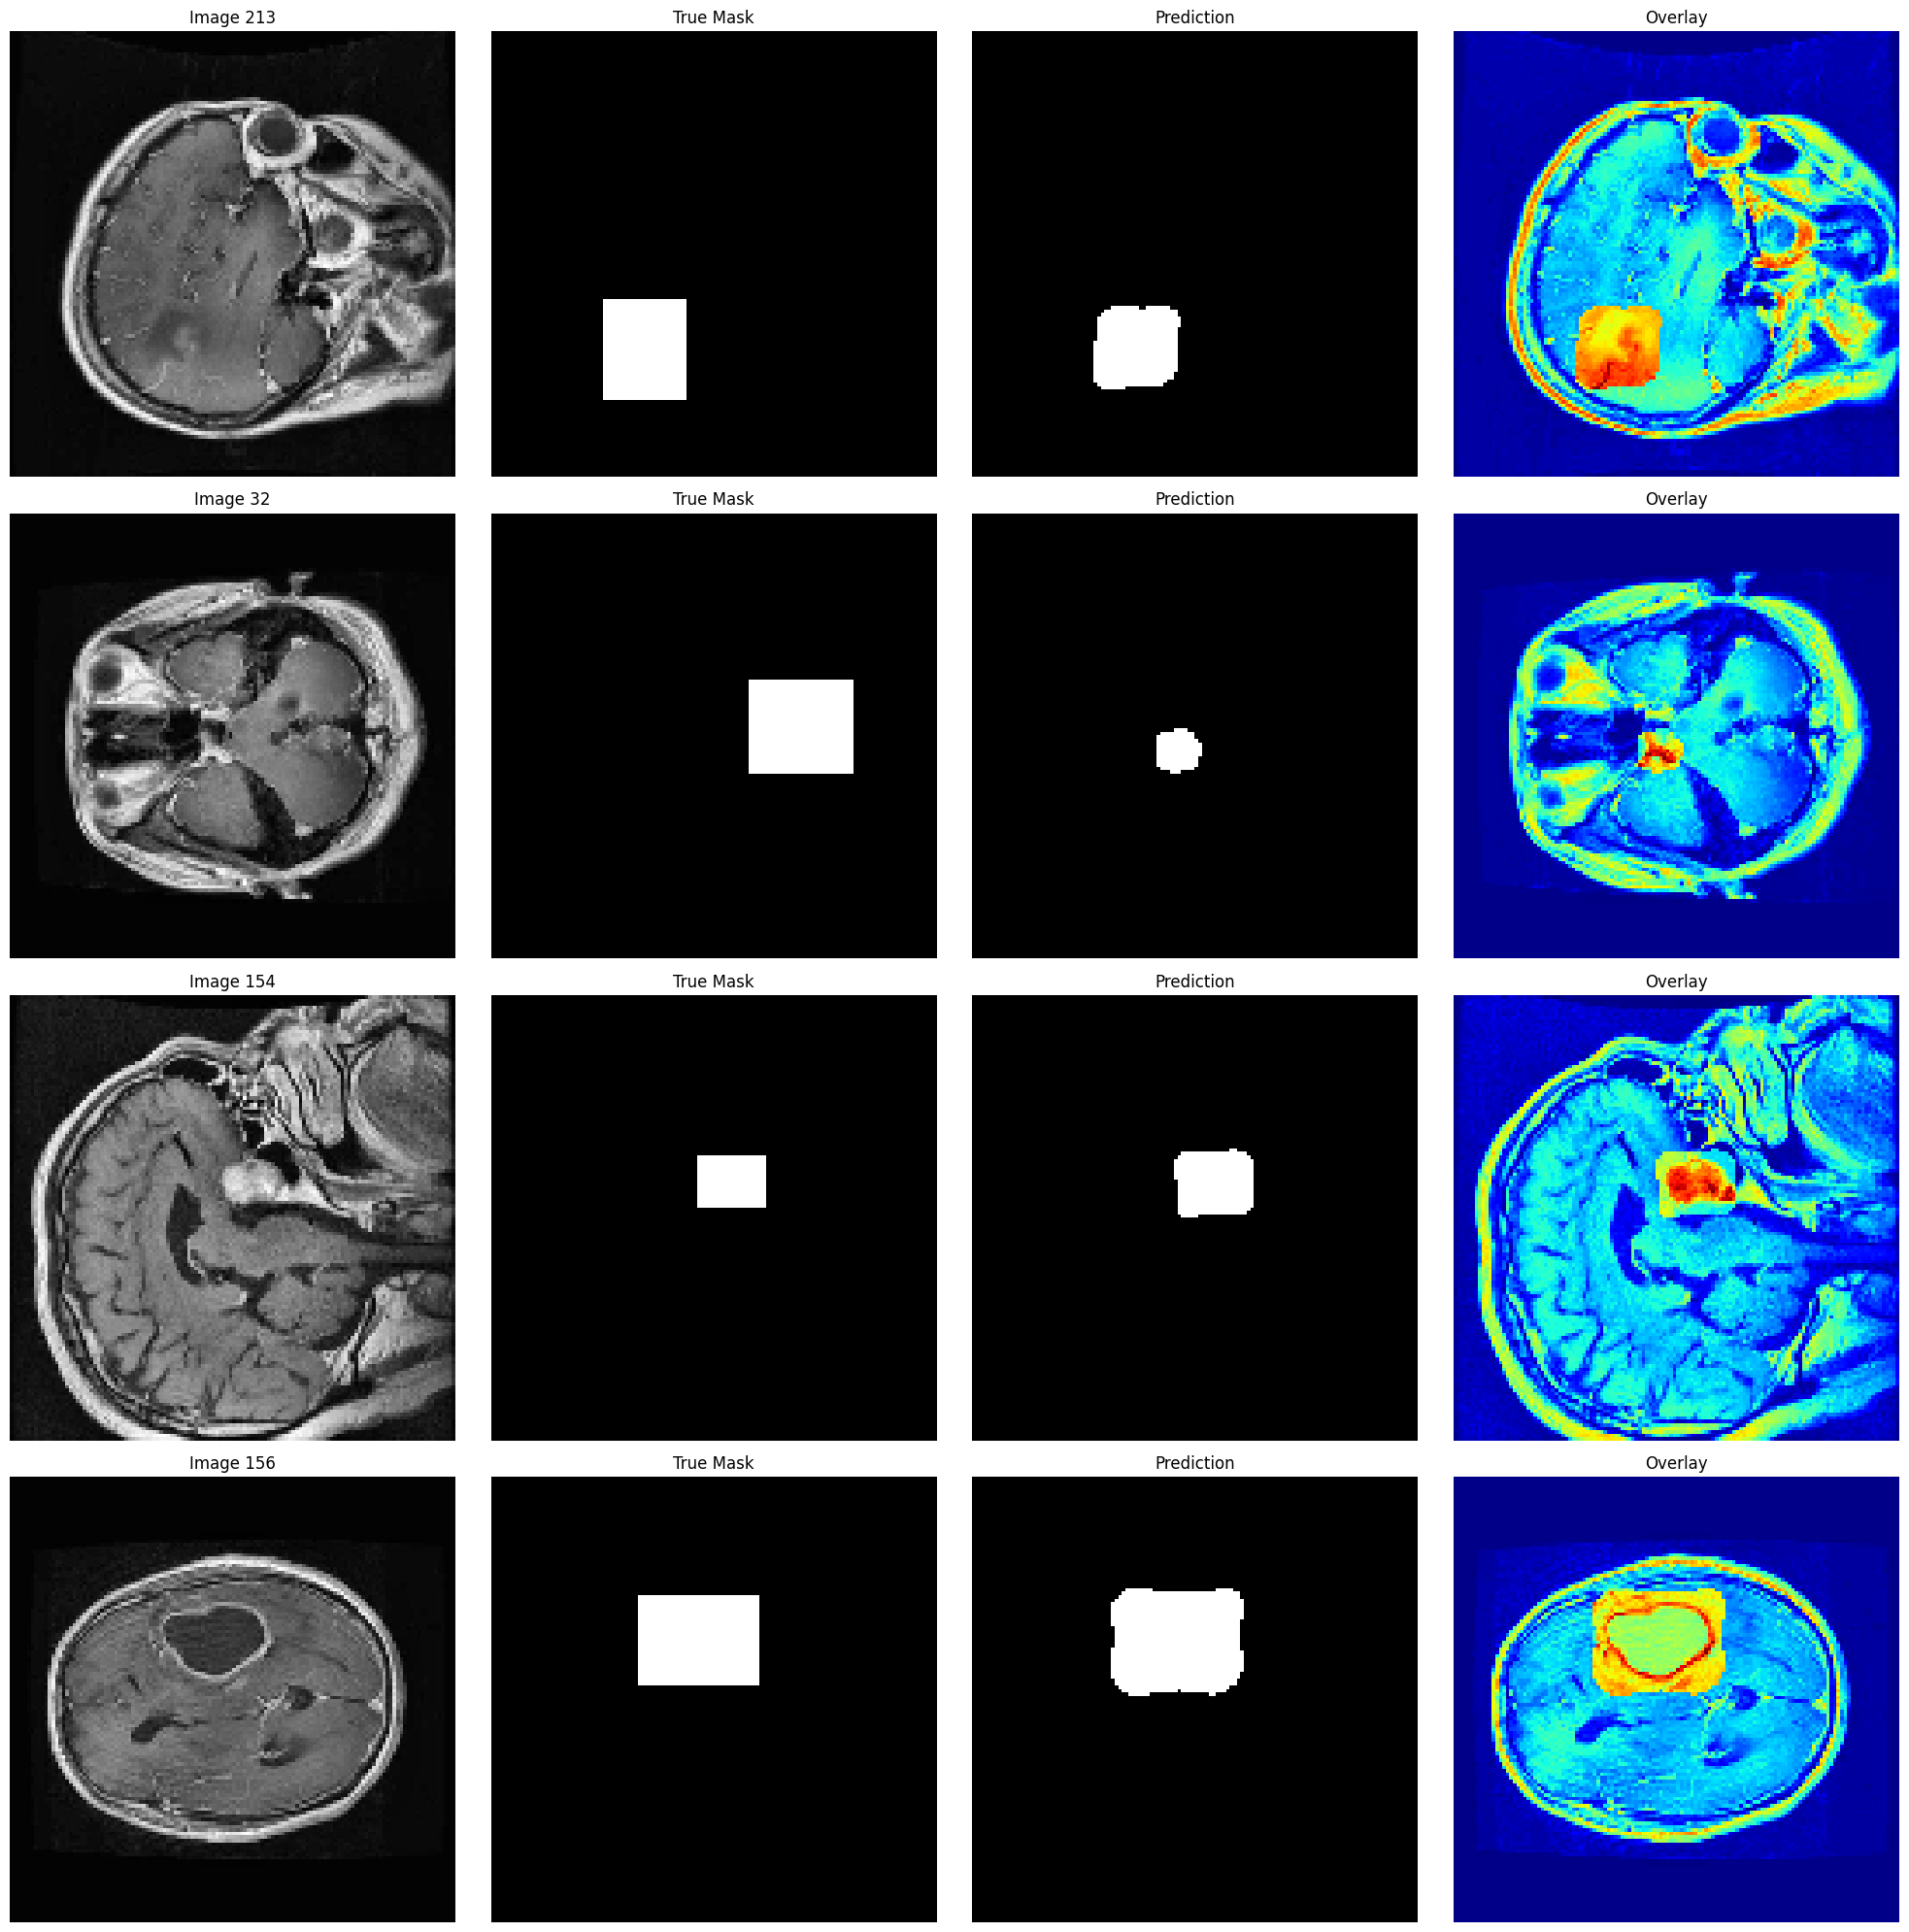

In [ ]:
# 1. Определение функций метрик
def dice_coef(y_true, y_pred, smooth=1):
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

def iou_metric(y_true, y_pred, smooth=1):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice_loss = 1 - dice_coef(y_true, y_pred)
    return bce + dice_loss

# 2. Загрузка модели
MODEL_PATH = '/content/drive/MyDrive/Colab_Models/brain_tumor_unetv2.h5'
model = tf.keras.models.load_model(MODEL_PATH, custom_objects={
    'combined_loss': combined_loss,
    'dice_coef': dice_coef,
    'iou_metric': iou_metric
})

# 3. Загрузка тестовых данных
test_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/test'
test_ann_file = os.path.join(test_dir, '_annotations.coco.json')
test_coco = COCO(test_ann_file)
test_img_ids = test_coco.getImgIds()


# 4. Функция загрузки и предобработки
def load_and_preprocess(coco, image_dir, image_id, img_size=(128, 128)):
    img_info = coco.loadImgs(image_id)[0]
    img_path = os.path.join(image_dir, img_info['file_name'])

    # Загрузка и конвертация в grayscale
    img = np.array(Image.open(img_path).convert('L'))  # 'L' - grayscale
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

    for ann in coco.loadAnns(coco.getAnnIds(imgIds=image_id)):
        mask = np.maximum(mask, coco.annToMask(ann))

    # Ресайз и нормализация
    img = cv2.resize(img, img_size) / 255.0
    mask = cv2.resize(mask, img_size) / 255.0

    return img[..., np.newaxis], mask[..., np.newaxis]  # Добавляем размерность канала

# 5. Функция визуализации
def show_predictions(model, coco, image_dir, img_ids, n_examples=4, img_size=(128, 128)):
    plt.figure(figsize=(20, 5*n_examples))
    selected_ids = random.sample(img_ids, min(n_examples, len(img_ids)))

    for i, img_id in enumerate(selected_ids):
        img_pre, true_mask_pre = load_and_preprocess(coco, image_dir, img_id, img_size)
        pred_mask = model.predict(np.expand_dims(img_pre, axis=0))[0,...,0]
        pred_bin = (pred_mask > 0.5).astype(np.float32)

        # Визуализация
        plt.subplot(n_examples, 4, i*4 + 1)
        plt.imshow(img_pre[...,0], cmap='gray')
        plt.title(f"Image {img_id}")
        plt.axis('off')

        plt.subplot(n_examples, 4, i*4 + 2)
        plt.imshow(true_mask_pre[...,0], cmap='gray')
        plt.title("True Mask")
        plt.axis('off')

        plt.subplot(n_examples, 4, i*4 + 3)
        plt.imshow(pred_bin, cmap='gray')
        plt.title("Prediction")
        plt.axis('off')

        plt.subplot(n_examples, 4, i*4 + 4)
        overlay = cv2.addWeighted((img_pre[...,0]*255).astype(np.uint8), 0.7,
                                (pred_bin*255).astype(np.uint8), 0.3, 0)
        plt.imshow(overlay, cmap='jet')
        plt.title("Overlay")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 6. Запуск визуализации
show_predictions(model, test_coco, test_dir, test_img_ids, n_examples=4)

Визуализация матрицы ошибок

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

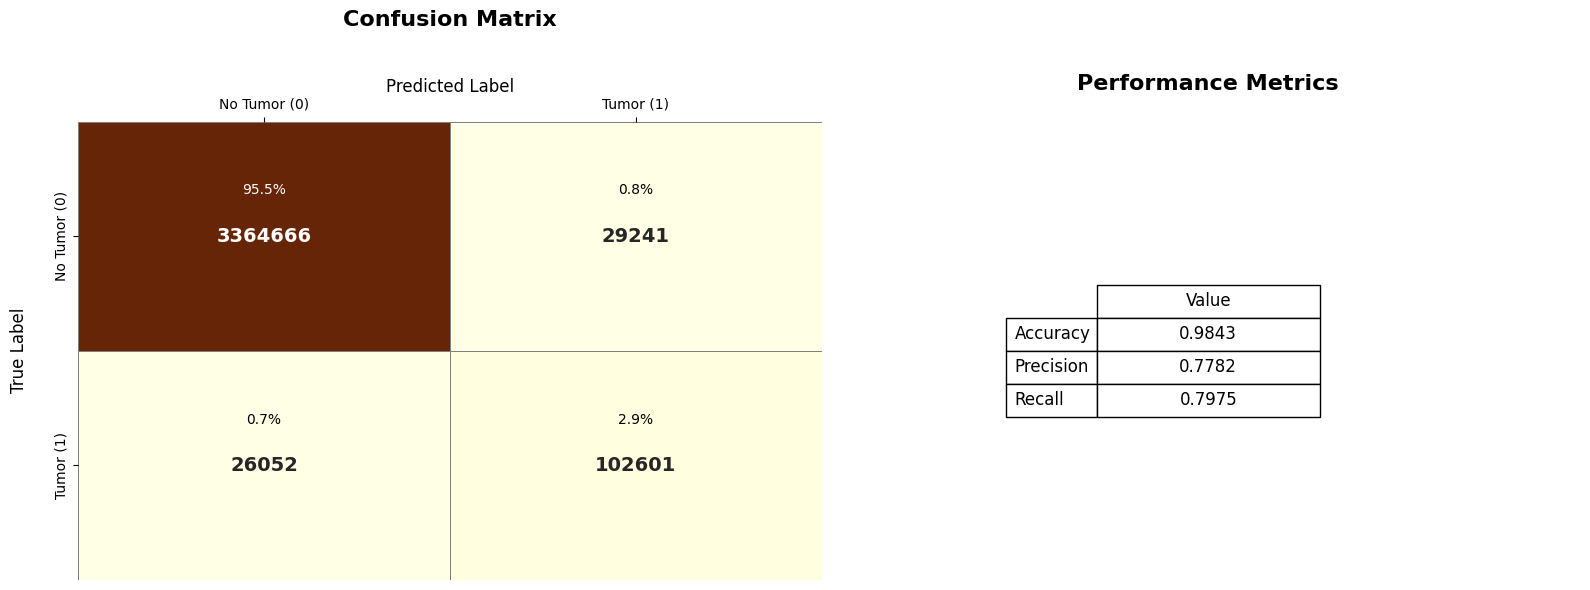

In [ ]:
y_true_all = []
y_pred_all = []

for img_id in test_img_ids:
    img, true_mask = load_image_and_mask(test_coco, test_dir, img_id)
    img_pre, true_mask_pre = preprocess_image_and_mask(img, true_mask, img_size=(128, 128))


    img_input = np.expand_dims(img_pre, axis=0)
    pred_mask = model.predict(img_input)[0, ..., 0]


    pred_bin = (pred_mask > 0.5).astype(np.uint8).flatten()
    true_bin = true_mask_pre[..., 0].astype(np.uint8).flatten()

    y_true_all.extend(true_bin)
    y_pred_all.extend(pred_bin)
# Вычисление матрицы ошибок
conf_matrix = confusion_matrix(y_true_all, y_pred_all)

# Создание фигуры с двумя subplots
plt.figure(figsize=(16, 6))

# Subplot 1: Улучшенная матрица ошибок
plt.subplot(1, 2, 1)
ax = sns.heatmap(conf_matrix,
                 annot=True,
                 fmt="d",
                 cmap="YlOrBr",
                 cbar=False,
                 annot_kws={"size": 14, "weight": "bold"},
                 xticklabels=["No Tumor (0)", "Tumor (1)"],
                 yticklabels=["No Tumor (0)", "Tumor (1)"],
                 linewidths=0.5,
                 linecolor="grey")

plt.title("Confusion Matrix\n", fontsize=16, fontweight='bold')
plt.xlabel("\nPredicted Label", fontsize=12)
plt.ylabel("True Label\n", fontsize=12)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Добавление дополнительной информации
total_samples = np.sum(conf_matrix)
for i in range(2):
    for j in range(2):
        percentage = conf_matrix[i,j] / total_samples * 100
        ax.text(j+0.5, i+0.3, f"{percentage:.1f}%",
                ha="center", va="center",
                color="black" if conf_matrix[i,j] < np.max(conf_matrix)/2 else "white",
                fontsize=10)

# Subplot 2: Дополнительные метрики
plt.subplot(1, 2, 2)
metrics = {
    "Accuracy": accuracy_score(y_true_all, y_pred_all),
    "Precision": precision_score(y_true_all, y_pred_all),
    "Recall": recall_score(y_true_all, y_pred_all),
}

# Создаем DataFrame для красивого отображения
metrics_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])
metrics_df['Value'] = metrics_df['Value'].map('{:.4f}'.format)

# Скрываем оси
plt.axis('off')
plt.title("Performance Metrics\n", fontsize=16, fontweight='bold')

# Создаем таблицу с метриками
table = plt.table(cellText=metrics_df.values,
                 rowLabels=metrics_df.index,
                 colLabels=metrics_df.columns,
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.3, 0.3])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)



plt.tight_layout()
plt.show()

Графики метрик

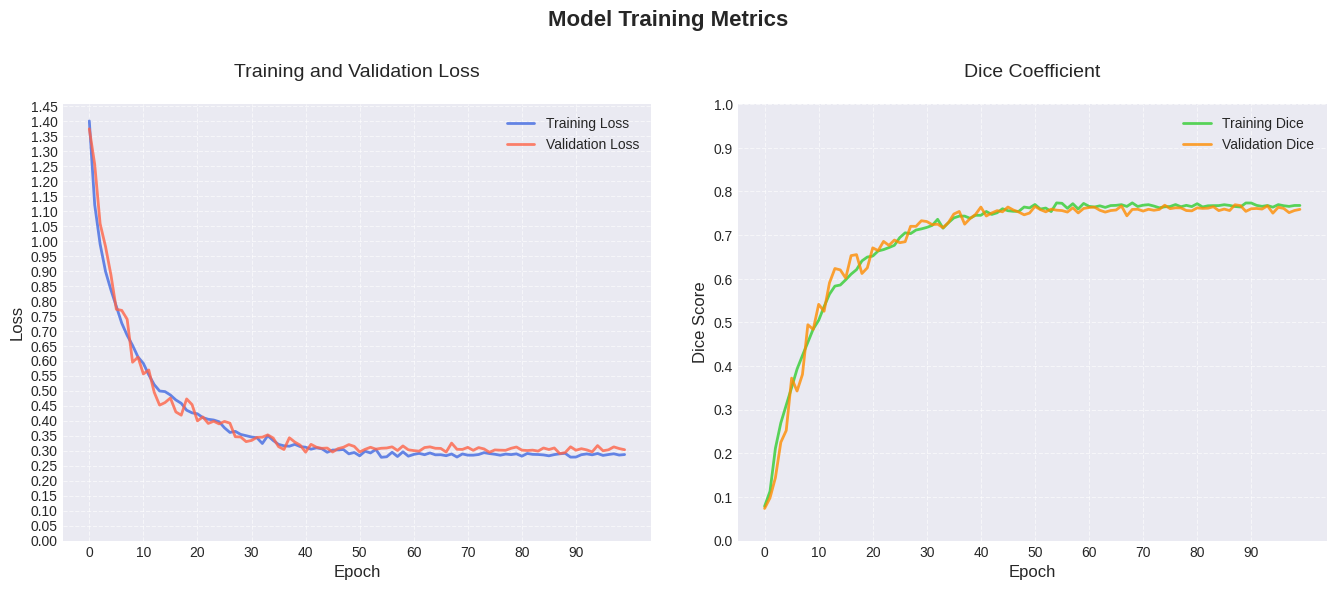

In [ ]:
# Загрузка данных
history_df = pd.read_csv('/content/drive/MyDrive/unet/training_history.csv')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')  # Красивый стиль с сеткой
plt.figure(figsize=(14, 6))

# График Loss
plt.subplot(1, 2, 1)
plt.plot(history_df['loss'], label='Training Loss', color='royalblue', linewidth=2, alpha=0.8)
plt.plot(history_df['val_loss'], label='Validation Loss', color='tomato', linewidth=2, alpha=0.8)
plt.title('Training and Validation Loss', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(np.arange(0, len(history_df), step=10))
plt.yticks(np.arange(0, max(history_df['loss'].max(), history_df['val_loss'].max()) + 0.1, step=0.05))
plt.legend(fontsize=10, framealpha=1, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

# График Dice
plt.subplot(1, 2, 2)
plt.plot(history_df['dice_coef'], label='Training Dice', color='limegreen', linewidth=2, alpha=0.8)
plt.plot(history_df['val_dice_coef'], label='Validation Dice', color='darkorange', linewidth=2, alpha=0.8)
plt.title('Dice Coefficient', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Dice Score', fontsize=12)
plt.xticks(np.arange(0, len(history_df), step=10))
plt.yticks(np.arange(0, 1.1, step=0.1))
plt.legend(fontsize=10, framealpha=1, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

# Общие настройки
plt.tight_layout(pad=3.0)  # Улучшенное расположение графиков
plt.suptitle('Model Training Metrics', y=1.02, fontsize=16, fontweight='bold')  # Общий заголовок
plt.show()